In [1]:
# imports and such
from pathlib import Path
from utils import load_plastchem, extract_feature_vecs, calculate_mfps
import matplotlib.pyplot as plt
from  matplotlib import rc
import numpy as np
from sklearn.manifold import TSNE
from rdkit.Chem import AllChem
import pandas as pd
from sklearn.cluster import KMeans
from pprint import pprint
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
from xgboost import XGBClassifier, XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay, r2_score, root_mean_squared_error, mean_absolute_error, balanced_accuracy_score, RocCurveDisplay, PrecisionRecallDisplay, make_scorer, average_precision_score
from sklearn.utils.class_weight import compute_sample_weight
from utils import load_plastchem, calculate_mfps, focal_binary_loss
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import StratifiedKFold, HalvingGridSearchCV, GridSearchCV
from xgboost import XGBClassifier
import pandas as pd
from collections import Counter
import joblib
import imblearn

In [7]:
data = np.load(Path.cwd() / "data" / "results_test.npz")
y_test, test_preds, test_probs, X_test = data["y_test"], data["test_preds"], data["test_probs"], data["X_test"]
dummy_preds, dummy_probs = data["dummy_preds"], data["dummy_probs"]
X_exploration, y_exploration = data["X_exploration"], data["y_exploration"]
search = joblib.load(Path.cwd() / "data"/"search.joblib")

In [3]:
from  matplotlib import rc
rc('font',**{'family':'sans-serif',
             'sans-serif':['Helvetica'],
             'size': 12, 
             'weight': 'normal'})
rc('text', usetex=True)

In [4]:
print(balanced_accuracy_score(y_test, test_preds))
print(classification_report(y_test, test_preds))
print(roc_auc_score(y_test, test_probs[:, 1]))

0.6388788098693758
              precision    recall  f1-score   support

         0.0       0.12      0.38      0.18        24
         1.0       0.98      0.90      0.94       689

    accuracy                           0.88       713
   macro avg       0.55      0.64      0.56       713
weighted avg       0.95      0.88      0.91       713

0.7625181422351233


### Visualizations for results

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


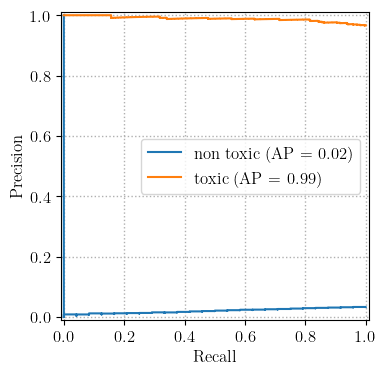

In [72]:
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
fig, ax = plt.subplots(figsize=(4,4))
# Precision Recall plot
ax.grid(zorder=0,linestyle='dotted', linewidth=1)
PrecisionRecallDisplay.from_predictions(y_test, test_probs[:, 1], pos_label=0, name="non toxic", ax=ax)
PrecisionRecallDisplay.from_predictions(y_test, test_probs[:, 1], pos_label=1, name="toxic", ax=ax)
#ax.set_title("Precision recall curve for minority class")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(loc="center right")
plt.savefig(Path.cwd() / "../report/pr_curve_min.eps", format="eps")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


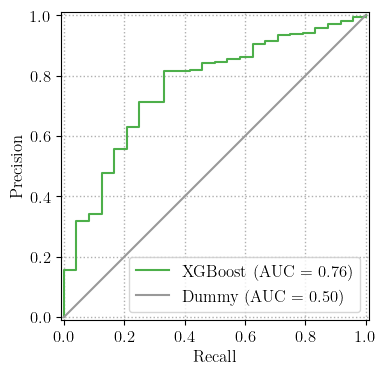

In [77]:
fig, ax = plt.subplots(figsize=(4,4))
ax.grid(zorder=0,linestyle='dotted', linewidth=1)
RocCurveDisplay.from_predictions(y_test, test_probs[:, 1], name="XGBoost", ax=ax, plot_chance_level=False, curve_kwargs={"c":"#4daf4a"})
RocCurveDisplay.from_predictions(y_test, dummy_probs[:, 1], name="Dummy", ax=ax, curve_kwargs={"c":"#999999"})
ax.legend()
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
plt.savefig(Path.cwd() / "../report/roc_auc.eps", format="eps")

In [8]:
best_model = search.best_estimator_

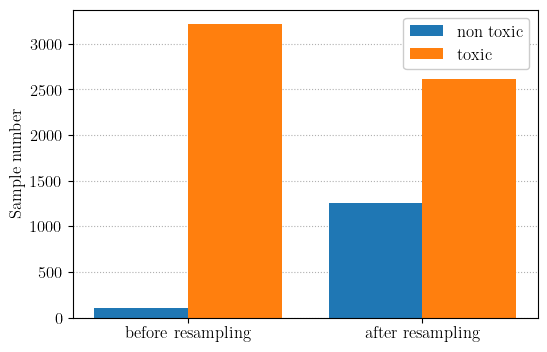

In [82]:
# SMOTE effect
before = Counter(y_exploration)
X_p = best_model.named_steps["pca"].fit_transform(X_exploration)
X_e, y_e = best_model.named_steps["smoteenn"].fit_resample(X_p, y_exploration)
after = Counter(y_e)

labels = sorted(before)
fig, ax = plt.subplots(figsize=(6,4))
x = np.arange(len(labels))
ax.grid(axis="y", zorder=0, linestyle="dotted")
ax.bar(x-0.2, [before[0], after[0]], width=0.4, label="non toxic", zorder=2)
ax.bar(x+0.2, [before[1], after[1]], width=0.4, label="toxic", zorder=2)
ax.set_xticks(x, ['before resampling', 'after resampling'])
ax.legend(loc="upper right", framealpha=1)
#ax.set_xlabel("Effect of SMOTE + ENN")
ax.set_ylabel("Sample number")
#ax.set_title("Sample amount before and after resampling")
plt.savefig(Path.cwd() / "../report/smote_effect.eps", format="eps")

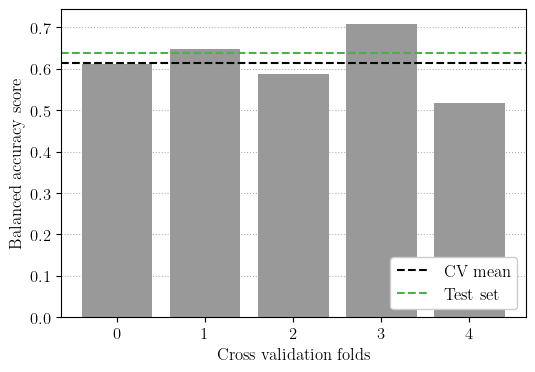

In [68]:
# CV Performance
best_idx = search.best_index_
fold_scores = [search.cv_results_[f"split{i}_test_score"][best_idx] for i in range(5)]

fig, ax = plt.subplots(figsize=(6,4))
ax.grid(axis="y", zorder=0, linestyle="dotted")
ax.bar(range(5), fold_scores, color="#999999", zorder=2)
ax.axhline(search.cv_results_["mean_test_score"][best_idx], color="k", ls="--", label="CV mean")
ax.axhline(balanced_accuracy_score(y_test, test_preds), color="#4daf4a", ls="--", label="Test set")
ax.set_xlabel("Cross validation folds")
ax.set_ylabel("Balanced accuracy score")
ax.legend(loc="lower right", framealpha=1)
#ax.set_title("5-fold cross validation performance")
plt.savefig(Path.cwd() / "../report/cv_performance.eps", format="eps")

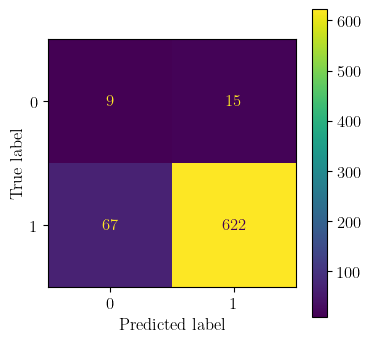

In [78]:
fig, ax = plt.subplots(figsize=(4,4))
cm = confusion_matrix(y_test, test_preds)
disp = ConfusionMatrixDisplay(cm)
disp.plot(ax=ax)
plt.savefig(Path.cwd() / "../report/cm_test.eps", format="eps")
plt.show()

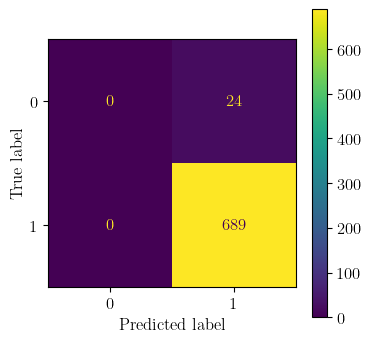

In [79]:
fig, ax = plt.subplots(figsize=(4,4))
cm = confusion_matrix(y_test, dummy_preds)
disp = ConfusionMatrixDisplay(cm)
disp.plot(ax=ax)
plt.savefig(Path.cwd() / "../report/cm_dummy.eps", format="eps")
plt.show()

### Values for GridSearch table

In [83]:
print(search.best_params_)
print(search.best_score_)

{'clf__colsample_bylevel': 0.75, 'clf__learning_rate': 0.001, 'clf__max_depth': 5, 'clf__n_estimators': 200, 'pca__n_components': 130, 'smoteenn__sampling_strategy': 0.4}
0.6145238784219323
